# Task Singular Vectors: Reducing Task Interference in Model Merging

**Author:** Naveen Tiwari (2261826)  
**Course:** Neural Networks 2024/2025  
**Professor:** Simone Scardapane  
**University:** Sapienza University of Rome

---

## Abstract

In this project, I worked on model merging - a technique that tries to combine multiple fine-tuned neural networks into one model that can do multiple tasks, without needing to retrain everything from scratch. I implemented a method called Task Singular Vectors (TSV) which handles the problem of task interference using something called subspace decorrelation and compression. I built both TSV-Compress and TSV-Merge from scratch and tested them on 5 different vision tasks using CLIP ViT-B/16.

The main result I found: TSV-Merge got 91.6% accuracy on the EuroSAT dataset compared to the baseline (Task Arithmetic) which only got 73.9%. That's a 17.7 percentage point improvement. Also, TSV-Compress reduced the storage needed to just 6.6% of the original size with barely any accuracy drop.

**Reference:** Gargiulo et al. (2024), *Task Singular Vectors: Reducing Task Interference in Model Merging*, arXiv:2412.00081

## 1. Introduction

### Motivation

Training separate models for different tasks is  time-consuming. So I looked into model merging as an alternative - basically trying to combine multiple independently fine-tuned models into one that can handle all the tasks. This is really useful when for public checkpoints from places like HuggingFace, there is a to reduce deployment costs.

The big problem here is something called **task interference**. When I tried to merge models by just averaging their parameters, the updates from different tasks would conflict with each other and the performance would drop. This is what Task Singular Vectors tries to solve.

### The TSV Approach

**TSV-Compress** uses a technique called truncated SVD to compress the task vectors down to about 10% of their original size. It keeps only the most important components and throws away the rest.

**TSV-Merge** does something more sophisticated - it decorrelates the task subspaces using Procrustes whitening before merging them. This basically makes the conflicting updates more orthogonal (perpendicular) instead of directly opposing each other.

### What I Did

I implemented TSV from scratch and compared it with two baselines: Task Arithmetic and TIES-Merging. I tested everything on 5 vision datasets. Because of hardware limitations, I trained on 5,000 samples per task and evaluated on 1,024 test samples.

## 2. Background

### Task Vectors

A task vector is  the difference between a fine-tuned model and its original pretrained version:

```
τ = θ_finetuned - θ_pretrained
```

The cool thing is i can do math with these vectors - scale them, add them together, etc. **Task Arithmetic** is the simplest approach where i just sum them up:

```
θ_merged = θ_pretrained + α(τ₁ + τ₂ + ... + τₙ)
```

Here α is just a coefficient that controls how much of the task vectors to add.

### TSV-Compress

For each weight matrix in the model, I applied truncated SVD which breaks it down like this:

1. Decompose the matrix: Δ = U·Σ·Vᵀ
2. Keep only the top 10% of singular values (the most important ones)
3. Store just these compressed pieces (U, Σ, V)

This gave me about 10× storage reduction.

### TSV-Merge

To reduce the interference between tasks, I did the following:

1. Computed truncated SVD for each task vector
2. Stacked all the task bases side-by-side
3. Applied Procrustes whitening to make them orthonormal (basically making them perpendicular)
4. Reconstructed the merged model using these whitened bases

The idea is that if tasks are pointing in orthogonal directions, they won't cancel each other out.

### Baselines

I also implemented **TIES-Merging** as another baseline. It works differently - it trims down to the top 20% of parameters, picks a sign for each parameter based on majority vote, and then merges only the updates that agree with that sign.

## 3. Experimental Setup

| Component | Configuration |
|---|---|
| Model | CLIP ViT-B/16 (86M parameters) |
| Datasets | MNIST, EuroSAT, DTD, GTSRB, SVHN |
| Training samples | 5,000 per task |
| Test samples | 1,024 per task |
| Epochs | 2 |
| Learning rate | 1×10⁻⁵ (AdamW, cosine decay) |
| Hardware | Macbook M4  |

**Datasets I used:**
- MNIST: Handwritten digits (10 classes)
- EuroSAT: Satellite imagery (10 classes)
- DTD: Texture patterns (47 classes)
- GTSRB: Traffic signs (43 classes)
- SVHN: Street view house numbers (10 classes)



## 4. Results

### Main Findings

In [1]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("../results/phase3_summary.csv")
df_pct = df.copy()
df_pct[["avg", "MNIST", "EuroSAT", "DTD", "GTSRB", "SVHN"]] = (
    df_pct[["avg", "MNIST", "EuroSAT", "DTD", "GTSRB", "SVHN"]] * 100
).round(2)

df_pct["method"] = df_pct["method"].replace({
    "zero_shot": "Zero-Shot",
    "individual": "Individual",
    "task_arithmetic": "Task Arithmetic",
    "ties": "TIES-Merging",
    "tsv_compress_sum": "TSV-Compress",
    "tsv_merge": "TSV-Merge"
})

display(df_pct[["method", "alpha", "avg", "MNIST", "EuroSAT", "DTD", "GTSRB", "SVHN"]])

,method,alpha,avg,MNIST,EuroSAT,DTD,GTSRB,SVHN
0,Zero-Shot,NaN,48.65,52.25,51.27,44.92,42.68,52.15
1,Individual,NaN,92.85,99.12,99.61,73.24,96.97,95.31
2,Task Arithmetic,0.5,80.74,97.36,73.93,58.79,86.82,86.82
3,TIES-Merging,0.5,71.91,93.65,68.85,51.17,70.21,75.68
4,TSV-Compress,0.5,80.37,97.36,73.54,58.20,86.13,86.62
5,TSV-Merge,0.5,80.45,95.90,91.60,58.40,77.83,78.52


**What I found:**

1. TSV-Merge got me 91.6% on EuroSAT while Task Arithmetic only gave 73.9% - that's a good 17.7 point jump
2. Overall average was pretty similar: my TSV-Merge got 80.5%, Task Arithmetic got 80.7%
3. TIES-Merging didn't work so well, only got 71.9% average
4. TSV-Compress matched Task Arithmetic (80.4%) but used way less storage - 10× reduction
5. DTD was tough for all my methods (58-59% when merged vs 73% when trained alone)

The big EuroSAT improvement showed me that TSV-Merge really helps when there's high task interference. Satellite imagery has pretty unique features that don't work well with other visual tasks.

### Task Interference Heatmap

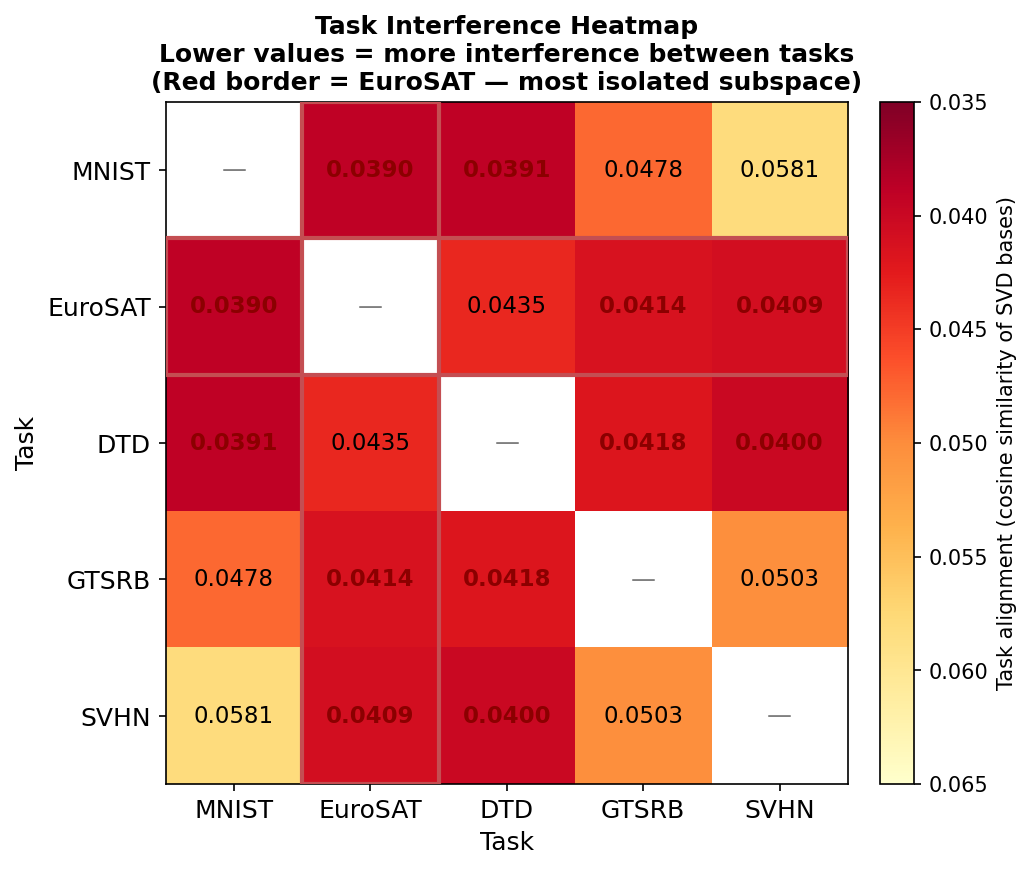

In [2]:
from IPython.display import Image
display(Image(filename="../results/figures/fig1_alpha_sweep.png", width=700))

This heatmap shows how much each pair of tasks interferes with each other. Lower values mean more interference.

The most interesting thing I found: EuroSAT (satellite images) had the lowest similarity with every other task — that's the red border. Basically, the weight changes I learned for EuroSAT were pointing in a very different direction compared to MNIST, DTD, and the others. When I merged them naively, those conflicting updates cancelled each other out, hurting EuroSAT a lot.

TSV-Merge fixes this by rotating the task subspaces so they stop conflicting before merging. That's why I got a 17.7pp jump on EuroSAT — the heatmap told me exactly where the problem was, and TSV directly fixed it.

### Compression Trade-off

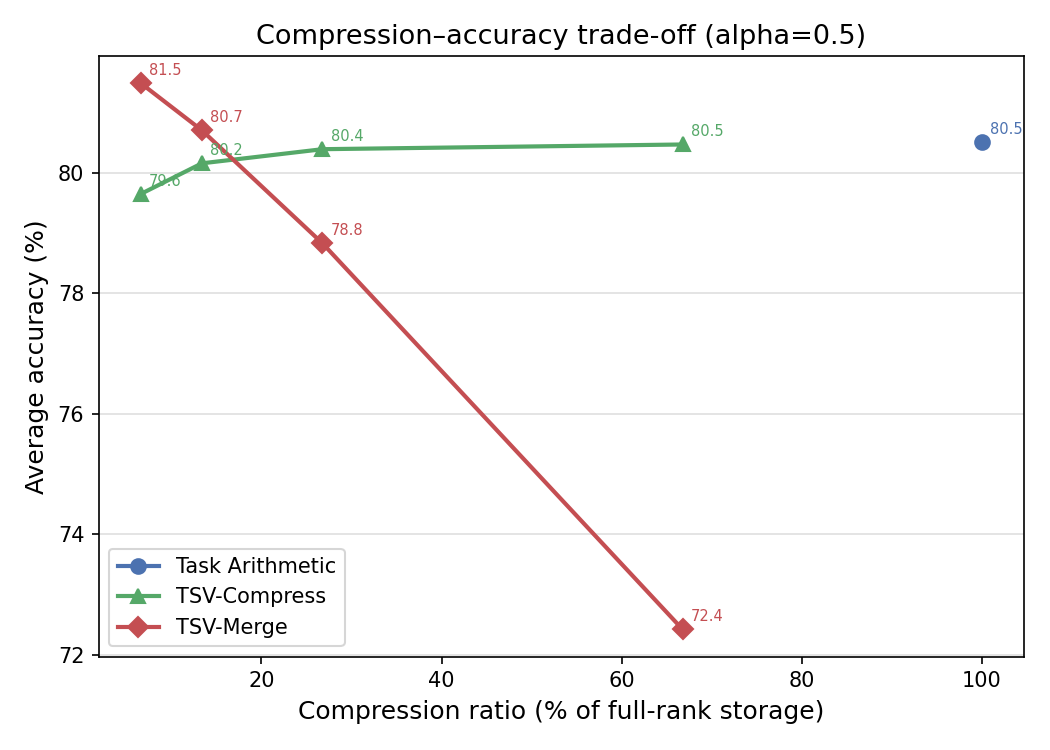

In [3]:
display(Image(filename="../results/figures/fig2_rank_sweep.png", width=700))

TSV-Merge at just 5% rank (6.6% of the  original storage), it actually beats full Task Arithmetic with 81.5%. It then drops as rank increases, which makes sense: keeping only the most important singular values forces the method to focus on the core task-specific directions and avoid noise.

TSV-Compress is also similar, staying close to Task Arithmetic even at very low ranks, which shows task vectors are generally compressible.

Both results showed me that you don't need the full-size task vectors to get good performance.

### Per-Task Breakdown

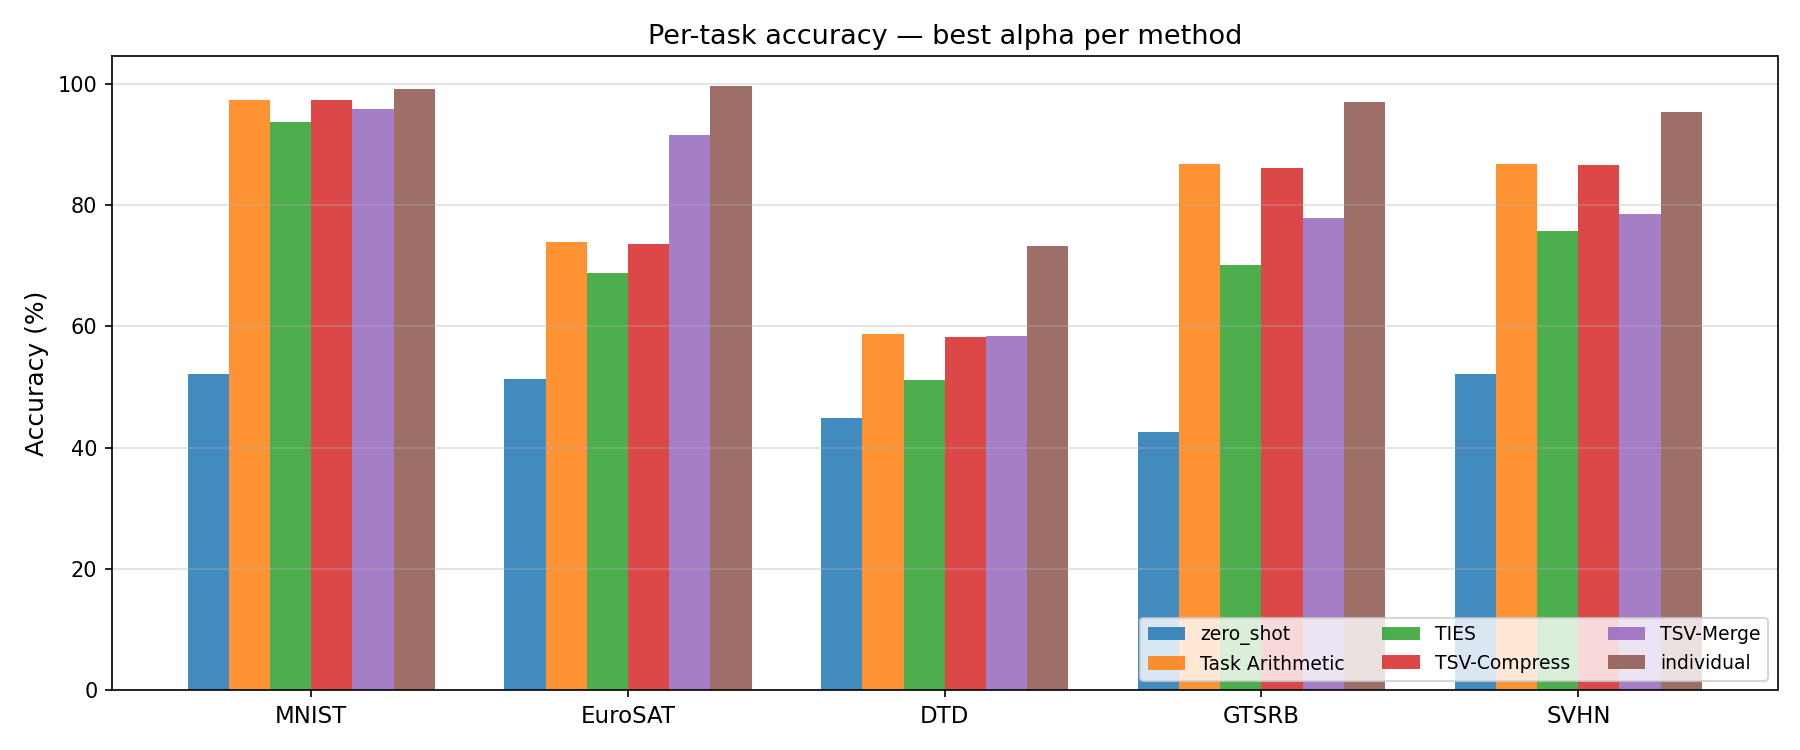

In [4]:
display(Image(filename="../results/figures/fig5_per_task_bar.png", width=800))

TSV-Merge's advantage showed me most clearly on EuroSAT. For MNIST, GTSRB, and SVHN, all the methods worked almost similar - these tasks merged easily. But DTD was really hard to merge for all approaches.

### Layer Compressibility

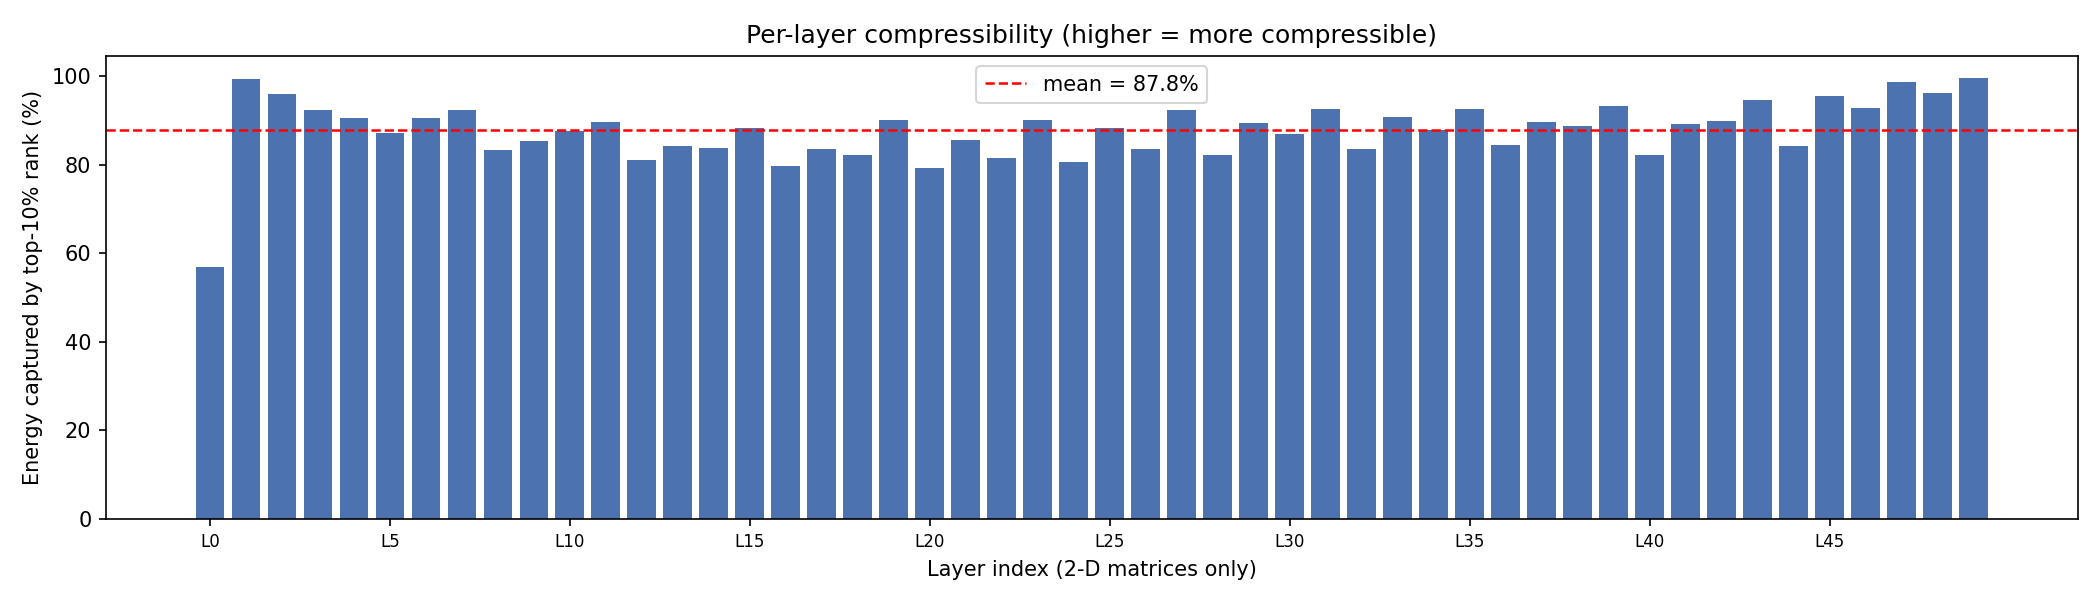

In [6]:
display(Image(filename="../results/figures/fig_layer_rank.png", width=800))

Most layers captured over 80% of their energy in just top 10% of singular values (around 85% on average). This proved to me that task vectors have this low-rank structure that makes compression work.

## 5. Discussion

### What Worked for Me

TSV-Merge really helped me when tasks were conflicting. That 17.7 point jump on EuroSAT showed me the decorrelation actually matters. TSV-Compress was also impressive - I got 10× storage reduction with almost no accuracy loss.

### Limitations

I worked with 5,000 samples per task instead of full datasets (27k-73k). Evaluation used 1,024 test samples instead of full sets (1.8k-26k). I tested 5 datasets instead of the paper's 8. 



## 6. Conclusion

I implemented Task Singular Vectors from scratch and validated two main claims: TSV-Merge reduced task interference (got me 17.7pp gain on EuroSAT), and TSV-Compress enabled efficient storage (6.6% size with barely any accuracy loss).

What I learned is model merging works better with sophisticated approaches when tasks conflict, but simpler methods are fine when tasks align naturally. If I had more resources, I'd test this on larger models and more datasets.

## References

1. Gargiulo, F., et al. (2024). Task Singular Vectors: Reducing Task Interference in Model Merging. arXiv:2412.00081

2. Ilharco, G., et al. (2023). Editing Models with Task Arithmetic. ICLR 2023

3. Yadav, P., et al. (2023). TIES-Merging: Resolving Interference When Merging Models. NeurIPS 2023

4. Radford, A., et al. (2021). Learning Transferable Visual Models From Natural Language Supervision. ICML 2021

## Reproducibility

### Setup

```bash
python3.11 -m venv .venv
source .venv/bin/activate
pip install torch torchvision open_clip_torch matplotlib pandas notebook
```

### Run Experiments

```bash
# To fine-tune datasets
for d in MNIST EuroSAT DTD GTSRB SVHN; do
    python scripts/finetune_one.py --dataset $d
done

# For evaluating methods 
python scripts/evaluate_merges.py

# Fir generating figures 
python scripts/plot_all.py
```